In [1]:
%pip install yfinance


[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import yfinance as yf
import numpy as np

In [3]:
import os

current_directory = os.getcwd()
print(current_directory)

/Users/bcslingluff/Desktop/DS4002/Project-2-Bitcoin/SCRIPTS


In [4]:
# Load Bitcoin Data
btc = pd.read_csv('../DATA/btc-usd-max.csv')
btc['date'] = pd.to_datetime(btc['snapped_at']).dt.date
btc = btc.rename(columns={'price': 'btc_price', 'market_cap': 'market_cap_btc', 'total_volume': 'trading_vol_btc'})
btc = btc[['date', 'btc_price', 'market_cap_btc', 'trading_vol_btc']]
btc['date'] = pd.to_datetime(btc['date'])

# Load 5-Year Breakeven Inflation Data
t5yie = pd.read_csv('../DATA/T5YIE.csv')
t5yie = t5yie.rename(columns={'observation_date': 'date', 'T5YIE': 'breakeven_5y'})
t5yie['date'] = pd.to_datetime(t5yie['date'])
t5yie['breakeven_5y'] = pd.to_numeric(t5yie['breakeven_5y'], errors='coerce')

btc.head(5) # Let Jupyter render the dataframe so you can inspect it

,date,btc_price,market_cap_btc,trading_vol_btc
0,2013-04-28,135.30,1.500518e+09,0.0
1,2013-04-29,141.96,1.575032e+09,0.0
2,2013-04-30,135.30,1.501657e+09,0.0
3,2013-05-01,117.00,1.298952e+09,0.0
4,2013-05-02,103.43,1.148668e+09,0.0


In [5]:
start_date = "2013-04-28"
tickers = ["^GSPC", "DX-Y.NYB"]

print("Downloading yfinance data...")
yf_data = yf.download(tickers, start=start_date)['Close']
yf_data = yf_data.reset_index()
yf_data = yf_data.rename(columns={'Date': 'date', '^GSPC': 'sp500_close', 'DX-Y.NYB': 'dxy_close'})
yf_data['date'] = pd.to_datetime(yf_data['date'])

yf_data.head(5)

[*********************100%***********************]  2 of 2 completed


Ticker,date,dxy_close,sp500_close
0,2013-04-29,82.150002,1593.609985
1,2013-04-30,81.730003,1597.569946
2,2013-05-01,81.639999,1582.699951
3,2013-05-02,82.209999,1597.589966
4,2013-05-03,82.099998,1614.420044


In [6]:
daily_df = pd.merge(btc, t5yie, on='date', how='left')
daily_df = pd.merge(daily_df, yf_data, on='date', how='left')

# Forward fill missing weekend data
daily_df[['breakeven_5y', 'sp500_close', 'dxy_close']] = daily_df[['breakeven_5y', 'sp500_close', 'dxy_close']].ffill()

daily_df['month'] = daily_df['date'].dt.to_period('M')
btc_monthly = daily_df.groupby('month')['btc_price'].mean().reset_index()
btc_monthly = btc_monthly.rename(columns={'btc_price': 'btc_monthly_avg'})

daily_df[['breakeven_5y', 'sp500_close', 'dxy_close']] = daily_df[['breakeven_5y', 'sp500_close', 'dxy_close']].bfill()
# Check for any remaining missing values
daily_df.isnull().sum()

date               0
btc_price          0
market_cap_btc     0
trading_vol_btc    0
breakeven_5y       0
dxy_close          0
sp500_close        0
month              0
dtype: int64

In [7]:
cpi = pd.read_csv('../DATA/CPIAUCSL.csv')
cpi = cpi.rename(columns={'observation_date': 'date', 'CPIAUCSL': 'cpi_raw'})
cpi['date'] = pd.to_datetime(cpi['date'])
cpi['month'] = cpi['date'].dt.to_period('M')
cpi['cpi_raw'] = cpi['cpi_raw'].interpolate(method='linear')
cpi['cpi_yoy_pct'] = cpi['cpi_raw'].pct_change(12, fill_method=None) * 100
cpi = cpi[['month', 'cpi_raw', 'cpi_yoy_pct']]

# Create Master DataFrames
monthly_master = pd.merge(cpi, btc_monthly, on='month', how='inner')
master_df = pd.merge(daily_df, cpi, on='month', how='left')
master_df = pd.merge(master_df, btc_monthly, on='month', how='left')

master_df['month'] = master_df['month'].astype(str)
monthly_master['month'] = monthly_master['month'].astype(str)

monthly_master = pd.merge(cpi, btc_monthly, on='month', how='inner').dropna()

master_df.to_csv('master_dataset_daily.csv', index=False)
monthly_master.to_csv('master_dataset_monthly.csv', index=False)
print("Data fully merged and saved!")

master_df.head()


Data fully merged and saved!


,date,btc_price,market_cap_btc,trading_vol_btc,breakeven_5y,dxy_close,sp500_close,month,cpi_raw,cpi_yoy_pct,btc_monthly_avg
0,2013-04-28,135.30,1.500518e+09,0.0,2.10,82.150002,1593.609985,2013-04,231.797,NaN,137.520000
1,2013-04-29,141.96,1.575032e+09,0.0,2.10,82.150002,1593.609985,2013-04,231.797,NaN,137.520000
2,2013-04-30,135.30,1.501657e+09,0.0,2.06,81.730003,1597.569946,2013-04,231.797,NaN,137.520000
3,2013-05-01,117.00,1.298952e+09,0.0,1.98,81.639999,1582.699951,2013-05,231.893,NaN,119.423968
4,2013-05-02,103.43,1.148668e+09,0.0,1.99,82.209999,1597.589966,2013-05,231.893,NaN,119.423968


In [8]:
master_df.tail()

,date,btc_price,market_cap_btc,trading_vol_btc,breakeven_5y,dxy_close,sp500_close,month,cpi_raw,cpi_yoy_pct,btc_monthly_avg
4678,2026-02-19,66456.353762,1.327724e+12,3.634839e+10,2.26,97.930000,6861.890137,2026-02,NaN,NaN,69960.164423
4679,2026-02-20,66918.684175,1.338095e+12,3.418084e+10,2.26,97.800003,6909.509766,2026-02,NaN,NaN,69960.164423
4680,2026-02-21,67970.294031,1.358591e+12,5.352826e+10,2.26,97.800003,6909.509766,2026-02,NaN,NaN,69960.164423
4681,2026-02-22,67977.909042,1.359066e+12,2.067981e+10,2.26,97.800003,6909.509766,2026-02,NaN,NaN,69960.164423
4682,2026-02-23,67585.117189,1.350654e+12,2.035477e+10,2.26,97.699997,6837.750000,2026-02,NaN,NaN,69960.164423


In [9]:
monthly_master.tail()

,month,cpi_raw,cpi_yoy_pct,btc_monthly_avg
149,2025-09,324.245,3.022572,112961.942993
150,2025-10,324.654,2.858718,114210.484440
151,2025-11,325.063,2.696444,96898.732343
152,2025-12,326.031,2.653304,89006.476648
153,2026-01,326.588,2.391201,90751.134026


In [10]:
%pip install plotly nbformat
%pip install --upgrade nbformat


[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# 1. Load the data
daily_df = pd.read_csv('master_dataset_daily.csv')
monthly_df = pd.read_csv('master_dataset_monthly.csv')

# Ensure dates are parsed correctly
daily_df['date'] = pd.to_datetime(daily_df['date'])
monthly_df['month'] = monthly_df['month'].astype(str) # Keep as string for categorical plotting

# 2. Calculate Daily Returns (Percentage Change)
daily_df['btc_return'] = daily_df['btc_price'].pct_change()
daily_df['sp500_return'] = daily_df['sp500_close'].pct_change()
daily_df['dxy_return'] = daily_df['dxy_close'].pct_change()

# 3. Calculate Monthly Returns
monthly_df['btc_monthly_return'] = monthly_df['btc_monthly_avg'].pct_change()

# Drop the first row of NaNs created by pct_change
daily_df = daily_df.dropna(subset=['btc_return', 'sp500_return'])
monthly_df = monthly_df.dropna(subset=['btc_monthly_return'])

print("Data loaded and returns calculated!")

Data loaded and returns calculated!


In [12]:
# Create a normalized dataframe where the first row of each asset equals 100
normalized_df = daily_df.copy()
normalized_df.set_index('date', inplace=True)

for col in ['btc_price', 'sp500_close', 'dxy_close']:
    normalized_df[col] = (normalized_df[col] / normalized_df[col].iloc[0]) * 100

# Plot using Plotly for interactive zooming and hovering
fig = px.line(normalized_df, x=normalized_df.index, y=['btc_price', 'sp500_close', 'dxy_close'],
              title='Relative Growth of Bitcoin, S&P 500, and US Dollar (Base 100)',
              labels={'value': 'Normalized Price', 'variable': 'Asset'})

# Update layout for better readability (log scale helps visualize Bitcoin's massive growth)
fig.update_layout(yaxis_type="log")
fig.show()

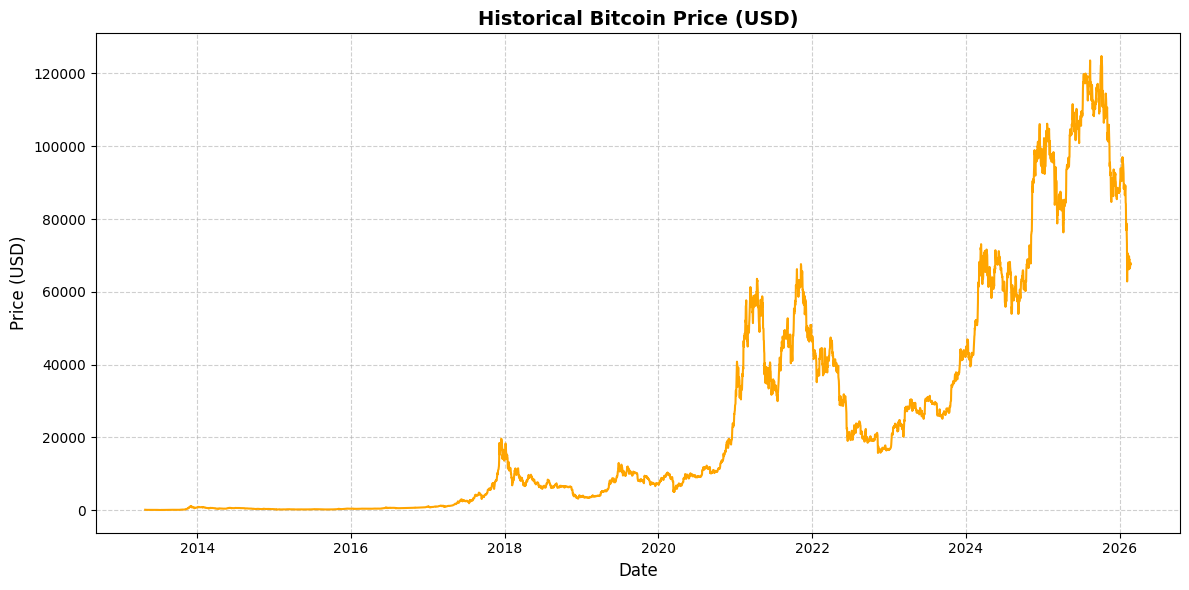

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Plot the raw Bitcoin price over time
plt.figure(figsize=(12, 6))
plt.plot(daily_df['date'], daily_df['btc_price'], color='orange', linewidth=1.5)

plt.title('Historical Bitcoin Price (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

# Use a logarithmic scale if you want to see early growth clearly
# plt.yscale('log') # Uncomment this line to see the log-scale version

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

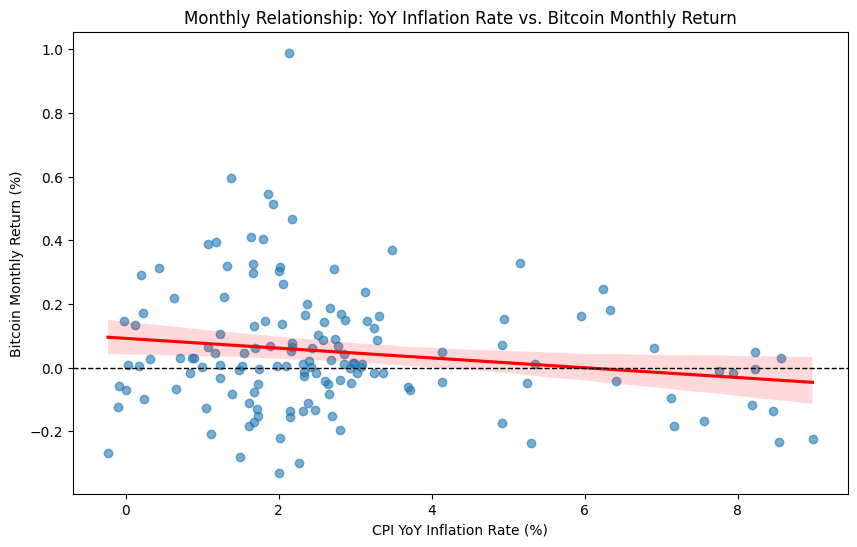

Correlation between CPI YoY and BTC Monthly Returns: -0.168


In [14]:
# Plot a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=monthly_df, x='cpi_yoy_pct', y='btc_monthly_return', 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})

plt.title('Monthly Relationship: YoY Inflation Rate vs. Bitcoin Monthly Return')
plt.xlabel('CPI YoY Inflation Rate (%)')
plt.ylabel('Bitcoin Monthly Return (%)')

# Add a horizontal line at 0 for reference
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()

# Print the exact correlation coefficient
monthly_corr = monthly_df['btc_monthly_return'].corr(monthly_df['cpi_yoy_pct'])
print(f"Correlation between CPI YoY and BTC Monthly Returns: {monthly_corr:.3f}")

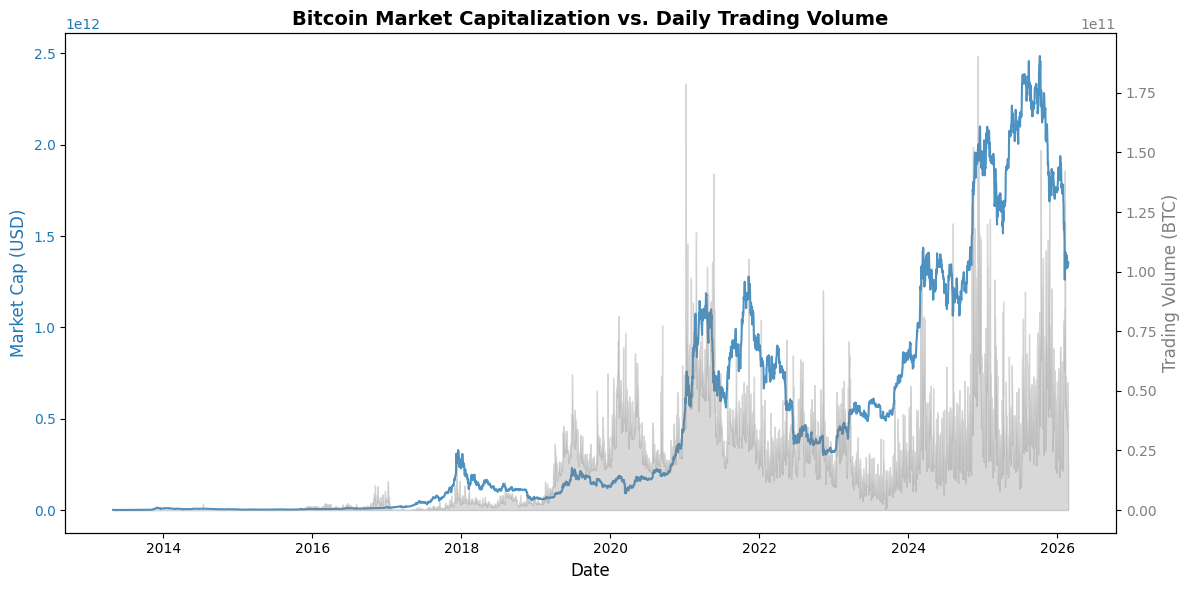

In [16]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axis 1: Market Cap
color1 = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Market Cap (USD)', color=color1, fontsize=12)
ax1.plot(daily_df['date'], daily_df['market_cap_btc'], color=color1, alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()  

# Axis 2: Trading Volume
color2 = 'tab:gray'
ax2.set_ylabel('Trading Volume (BTC)', color=color2, fontsize=12)
# Using a bar chart or a filled line for volume helps visually separate it from Market Cap
ax2.fill_between(daily_df['date'], daily_df['trading_vol_btc'], color=color2, alpha=0.3)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Bitcoin Market Capitalization vs. Daily Trading Volume', fontsize=14, fontweight='bold')
fig.tight_layout() 
plt.show()

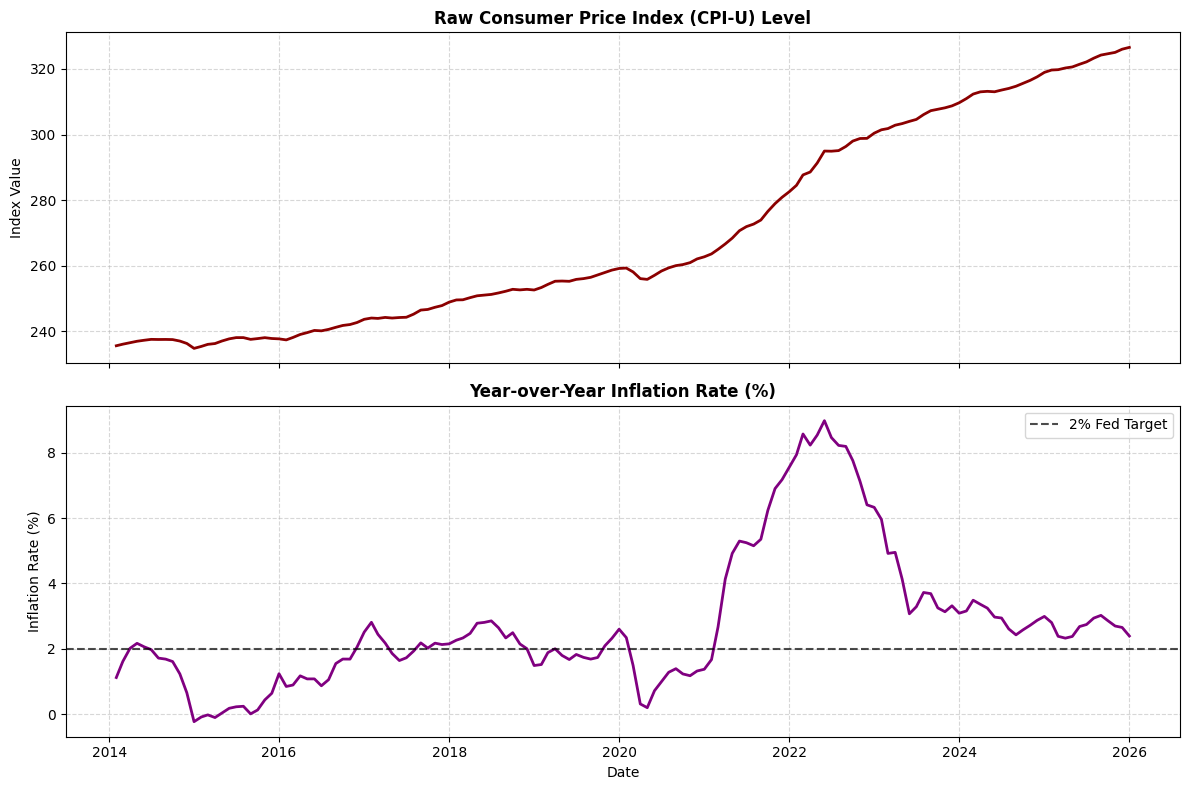

In [17]:
# Convert month string back to datetime for clean plotting
plot_monthly = monthly_df.copy()
plot_monthly['month_dt'] = pd.to_datetime(plot_monthly['month'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Subplot 1: Raw CPI Level
ax1.plot(plot_monthly['month_dt'], plot_monthly['cpi_raw'], color='darkred', linewidth=2)
ax1.set_title('Raw Consumer Price Index (CPI-U) Level', fontsize=12, fontweight='bold')
ax1.set_ylabel('Index Value')
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: YoY Inflation Rate
ax2.plot(plot_monthly['month_dt'], plot_monthly['cpi_yoy_pct'], color='purple', linewidth=2)
ax2.set_title('Year-over-Year Inflation Rate (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Inflation Rate (%)')
ax2.set_xlabel('Date')
ax2.axhline(2.0, color='black', linestyle='--', alpha=0.7, label='2% Fed Target') # 2% target line
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

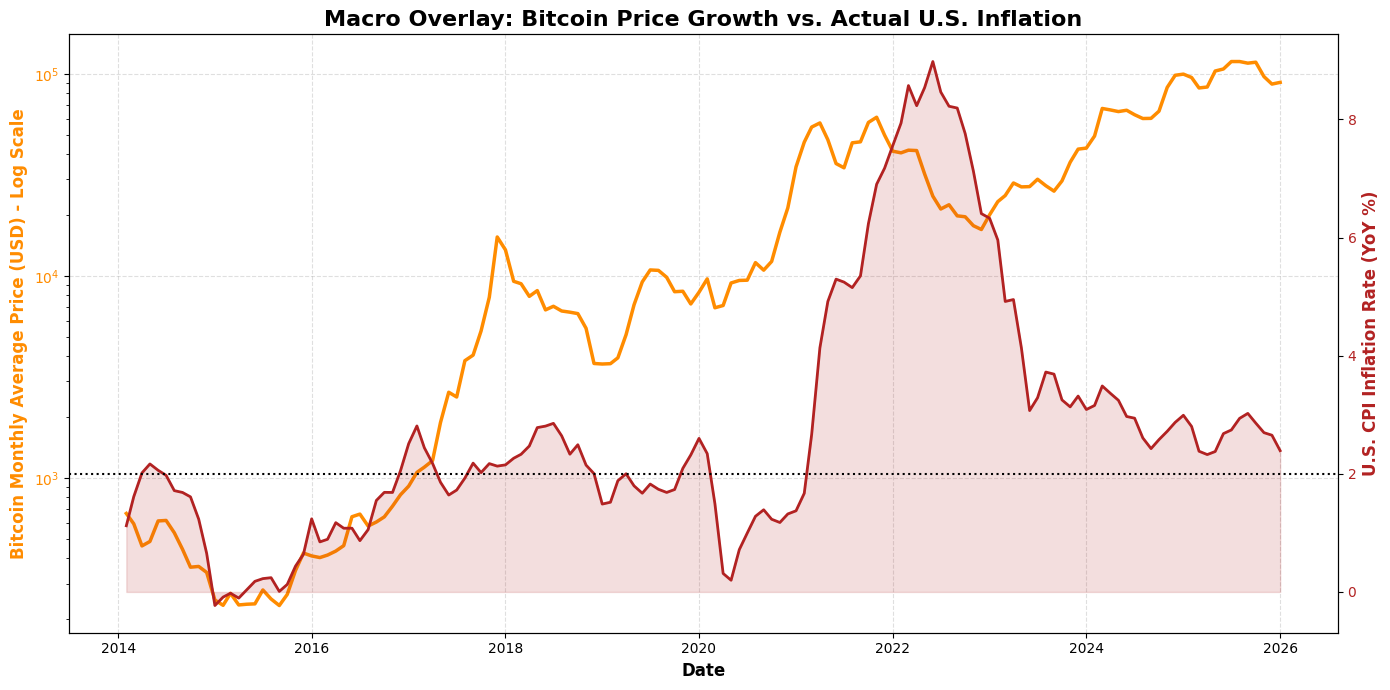

In [18]:
# Convert the month column to a datetime object for clean plotting on the x-axis
plot_df = monthly_df.copy()
plot_df['month_dt'] = pd.to_datetime(plot_df['month'])

# Create a figure and primary axis
fig, ax1 = plt.subplots(figsize=(14, 7))

# Axis 1 (Left): Bitcoin Price on a Logarithmic Scale
color_btc = 'darkorange'
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Bitcoin Monthly Average Price (USD) - Log Scale', color=color_btc, fontsize=12, fontweight='bold')
ax1.plot(plot_df['month_dt'], plot_df['btc_monthly_avg'], color=color_btc, linewidth=2.5, label='BTC Price')
ax1.tick_params(axis='y', labelcolor=color_btc)
ax1.set_yscale('log') # Log scale prevents early years from looking completely flat
ax1.grid(True, linestyle='--', alpha=0.4)

# Axis 2 (Right): YoY Inflation Rate
ax2 = ax1.twinx()
color_cpi = 'firebrick'
ax2.set_ylabel('U.S. CPI Inflation Rate (YoY %)', color=color_cpi, fontsize=12, fontweight='bold')
# Fill the area under the inflation line slightly to make it visually distinct from the BTC line
ax2.fill_between(plot_df['month_dt'], plot_df['cpi_yoy_pct'], color=color_cpi, alpha=0.15)
ax2.plot(plot_df['month_dt'], plot_df['cpi_yoy_pct'], color=color_cpi, linewidth=2, label='Inflation Rate')
ax2.tick_params(axis='y', labelcolor=color_cpi)

# Add a horizontal line at the Fed's 2% inflation target for context
ax2.axhline(2.0, color='black', linestyle=':', linewidth=1.5, label='2% Fed Target')

plt.title('Macro Overlay: Bitcoin Price Growth vs. Actual U.S. Inflation', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()